In [21]:
# Objective:
# This notebook builds a complete, production-ready machine learning pipeline to predict customer churn using the IBM Telco Customer Churn dataset.
# It covers end-to-end steps including data cleaning, preprocessing via ColumnTransformer, training and comparing Logistic Regression and Random Forest models, hyperparameter tuning with GridSearchCV (ROC-AUC), and full evaluation with confusion matrix, ROC curve, and feature importance plots.
# The best pipeline is saved using joblib and supports single-customer and batch predictions./
# URL: https://f1a11c181b13cdc239.gradio.live

In [3]:
# GPU Check and Environment Setup
import sys, os, torch

print("=" * 55)  # Print separator line for visual formatting

if torch.cuda.is_available():  # Check if CUDA GPU is available
    print(f"GPU  : {torch.cuda.get_device_name(0)}")  # Print GPU model name
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")  # Convert bytes to GB
    DEVICE = "cuda"  # Set device to GPU
else:  # No GPU detected
    print("WARNING: No GPU. Go to Runtime > Change runtime type > GPU")  # Colab-specific instruction
    DEVICE = "cpu"  # Fallback to CPU

print(f"Device  : {DEVICE}")  # Show active device
print(f"Python  : {sys.version.split()[0]}")  # Show Python version
print(f"PyTorch : {torch.__version__}")  # Show PyTorch version
print("=" * 55)  # Closing separator

GPU  : Tesla T4
VRAM : 15.6 GB
Device  : cuda
Python  : 3.12.13
PyTorch : 2.10.0+cu128


In [4]:
# Install Dependencies
import subprocess, sys

# List of required packages with minimum version specifications
pkgs = [
    "transformers>=4.40.0",   # HuggingFace transformer models (BERT)
    "datasets>=2.19.0",       # Easy dataset loading and processing
    "accelerate>=0.29.0",     # Optimized training on GPU/TPU
    "gradio>=4.28.0",         # Web app deployment interface
    "evaluate>=0.4.0",        # Model evaluation metrics
    "scikit-learn>=1.4.0",    # ML metrics and utilities
    "seaborn>=0.13.0",        # Statistical data visualization
    "matplotlib>=3.8.0",      # Core plotting library
]

# Run pip install quietly (-q flag) with all packages, raise error if fails
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)

# Import installed libraries to verify successful installation
import transformers, datasets as ds_lib, gradio as gr, evaluate

# Display version numbers to confirm installation
print(f"transformers : {transformers.__version__}")
print(f"datasets     : {ds_lib.__version__}")
print(f"gradio       : {gr.__version__}")
print("All packages ready.")

transformers : 5.0.0
datasets     : 4.0.0
gradio       : 5.50.0
All packages ready.


In [10]:
# Load & Explore Dataset
# Using fancyzhx/ag_news — the standard HuggingFace AG News mirror.
# Splits  : train (120,000) + test (7,600)
# Labels  : 0=World  1=Sports  2=Business  3=Sci/Tech  (0-based, confirmed)
# Columns : text (str), label (int)
from datasets import load_dataset
import pandas as pd

# Load AG News dataset (120K training, 7.6K test samples with 4 news categories)
print("Loading fancyzhx/ag_news ...")
dataset = load_dataset("fancyzhx/ag_news")
print(dataset)  # Display dataset splits and sample counts

# Class definitions (0-based, matches dataset label dtype)
LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]  # Category names for human readability
NUM_LABELS  = len(LABEL_NAMES)  # Total classes: 4
LABEL2ID    = {n: i for i, n in enumerate(LABEL_NAMES)}  # Map category name → integer ID
ID2LABEL    = {i: n for i, n in enumerate(LABEL_NAMES)}  # Map integer ID → category name

# Convert training split to pandas DataFrame for easier analysis
train_df = dataset["train"].to_pandas()
train_df["label"] = train_df["label"].astype(int)  # Ensure labels are integers

# Print dataset statistics
print(f"\nTraining samples : {len(train_df):,}")
print(f"Test samples     : {len(dataset['test']):,}")
print(f"Unique labels    : {sorted(train_df['label'].unique().tolist())}")  # Should be [0,1,2,3]
print(f"Columns          : {dataset['train'].column_names}")  # Expected: ['text', 'label']

# Display class distribution with percentages
print("\nClass distribution (train):")
for lbl, count in train_df["label"].value_counts().sort_index().items():
    pct = count / len(train_df) * 100
    print(f"  {lbl}  {LABEL_NAMES[int(lbl)]:<10}: {count:>6,}  ({pct:.1f}%)")

# Show 4 random sample records to verify data quality
print("\nSample records:")
for _, row in train_df.sample(4, random_state=42).iterrows():
    lbl     = int(row["label"])
    preview = str(row["text"])[:85]  # Truncate long texts for display
    print(f"  [{LABEL_NAMES[lbl]}] {preview}")

Loading fancyzhx/ag_news ...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Training samples : 120,000
Test samples     : 7,600
Unique labels    : [0, 1, 2, 3]
Columns          : ['text', 'label']

Class distribution (train):
  0  World     : 30,000  (25.0%)
  1  Sports    : 30,000  (25.0%)
  2  Business  : 30,000  (25.0%)
  3  Sci/Tech  : 30,000  (25.0%)

Sample records:
  [Business] BBC set for major shake-up, claims newspaper London - The British Broadcasting Corpor
  [Business] Marsh averts cash crunch Embattled insurance broker #39;s banks agree to waive clause
  [Sports] Jeter, Yankees Look to Take Control (AP) AP - Derek Jeter turned a season that starte
  [Sci/Tech] Flying the Sun to Safety When the Genesis capsule comes back to Earth with its sample


In [11]:
# Tokenization, Dataset Preparation and Splits
import torch
from transformers import AutoTokenizer

# Model configuration
MODEL_NAME = "bert-base-uncased"  # Pre-trained BERT model with lowercase vocabulary
MAX_LENGTH = 128  # Maximum sequence length (truncate longer texts, pad shorter ones)
TOKENIZER  = AutoTokenizer.from_pretrained(MODEL_NAME)  # Load BERT's tokenizer

# Display tokenizer information
print(f"Tokenizer  : {MODEL_NAME}  |  vocab: {TOKENIZER.vocab_size:,}  |  max_len: {MAX_LENGTH}")

# Tokenization function: converts text to input_ids, attention_mask, token_type_ids
def tokenize_fn(examples):
    return TOKENIZER(examples["text"], padding="max_length",  # Pad all sequences to MAX_LENGTH
                     truncation=True, max_length=MAX_LENGTH)  # Truncate longer sequences

# Apply tokenization to entire dataset in batches (1000 samples per batch)
print("Tokenizing ...")
tokenized = dataset.map(tokenize_fn, batched=True, batch_size=1000, desc="Tokenizing")
tokenized = tokenized.rename_column("label", "labels")  # Rename to match BERT's expected input
tokenized.set_format(type="torch",  # Convert to PyTorch tensors for training
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"])

# Create train/validation split (90% train, 10% validation) with stratification to preserve class balance
split         = tokenized["train"].train_test_split(
                    test_size=0.1, seed=42, stratify_by_column="labels")
train_dataset = split["train"]   # 108K samples for training
val_dataset   = split["test"]    # 12K samples for validation
test_dataset  = tokenized["test"]  # 7.6K samples for final evaluation

# Print dataset sizes
print(f"Train : {len(train_dataset):,}  |  Val : {len(val_dataset):,}  |  Test : {len(test_dataset):,}")

# Verify tokenization worked correctly by inspecting first training sample
s = train_dataset[0]
print(f"Sample input_ids shape : {tuple(s['input_ids'].shape)}")  # Should be (128,) - sequence length
print(f"Sample label           : {s['labels'].item()} ({LABEL_NAMES[s['labels'].item()]})")  # Category name

Tokenizer  : bert-base-uncased  |  vocab: 30,522  |  max_len: 128
Tokenizing ...


Tokenizing:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train : 108,000  |  Val : 12,000  |  Test : 7,600
Sample input_ids shape : (128,)
Sample label           : 1 (Sports)


In [13]:
# Loading bert-base-uncased for Sequence Classification
from transformers import AutoModelForSequenceClassification

# Load BERT with custom classification head (replaces BERT's pre-trained head)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,                    # "bert-base-uncased" - pre-trained weights
    num_labels = NUM_LABELS,       # 4 output classes (World, Sports, Business, Sci/Tech)
    id2label   = ID2LABEL,         # Reverse mapping: index → category name
    label2id   = LABEL2ID,         # Forward mapping: category name → index
    hidden_dropout_prob = 0.3,     # Dropout on hidden layers (reduces overfitting)
    attention_probs_dropout_prob = 0.1,  # Dropout on attention weights
)

# Count model parameters
total_p     = sum(p.numel() for p in model.parameters())  # All parameters (frozen + trainable)
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)  # Only trainable ones

# Display model architecture summary
print(f"Model           : {MODEL_NAME}")
print(f"Total params    : {total_p:,}")        # ~110M parameters for bert-base-uncased
print(f"Trainable params: {trainable_p:,}")    # Same as total since we fine-tune all layers
print(f"Head            : Linear({model.config.hidden_size} -> {NUM_LABELS})")  # 768 → 4
print(f"Dropout         : hidden=0.3 | attention=0.1")

# Move model to GPU/CPU for training
model = model.to(DEVICE)
print(f"\nLoaded on: {DEVICE}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model           : bert-base-uncased
Total params    : 109,485,316
Trainable params: 109,485,316
Head            : Linear(768 -> 4)
Dropout         : hidden=0.3 | attention=0.1

Loaded on: cuda


In [14]:
#  Training Arguments + Compute_Metrics
import numpy as np
import evaluate as hf_evaluate
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

# Load evaluation metrics from HuggingFace evaluate library
acc_metric = hf_evaluate.load("accuracy")  # Accuracy: correct predictions / total predictions
f1_metric  = hf_evaluate.load("f1")        # F1-score: harmonic mean of precision and recall

# Function to compute metrics during evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred  # Model outputs (logits) and ground truth labels
    preds = np.argmax(logits, axis=-1)  # Get predicted class (highest logit value)
    acc = acc_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    return {"accuracy": round(acc, 4), "f1": round(f1, 4)}  # Round to 4 decimal places

# Determine batch size based on GPU VRAM (T4 has 15GB → batch 32, else fallback to 16)
USE_FP16   = torch.cuda.is_available()  # Enable mixed precision training if GPU available
BATCH_SIZE = (32 if torch.cuda.is_available() and
              torch.cuda.get_device_properties(0).total_memory > 14e9 else 16)

# Training configuration - optimized for BERT fine-tuning
training_args = TrainingArguments(
    output_dir                  = "./bert_news_model",  # Save checkpoints here
    logging_dir                 = "./logs",             # Log files directory
    learning_rate               = 2e-5,                 # Typical BERT fine-tuning LR (2e-5 to 5e-5)
    per_device_train_batch_size = BATCH_SIZE,           # Samples per GPU for training
    per_device_eval_batch_size  = BATCH_SIZE * 2,       # Larger eval batch (no gradients)
    num_train_epochs            = 3,                    # Full passes through training data
    weight_decay                = 0.01,                 # L2 regularization to prevent overfitting
    warmup_ratio                = 0.06,                 # 6% steps for LR warmup (gradual start)
    eval_strategy               = "epoch",              # Evaluate at end of each epoch
    save_strategy               = "epoch",              # Save checkpoint each epoch
    load_best_model_at_end      = True,                 # Restore best model after training
    metric_for_best_model       = "f1",                 # Use F1 score to select best model
    greater_is_better           = True,                 # Higher F1 = better model
    fp16                        = USE_FP16,             # Mixed precision (faster + less memory)
    dataloader_num_workers      = 2,                    # Parallel data loading threads
    dataloader_pin_memory       = True,                 # Faster CPU→GPU data transfer
    logging_steps               = 100,                  # Print metrics every 100 steps
    report_to                   = "none",               # Disable wandb/tensorboard logging
    seed                        = 42,                   # Reproducibility
)

# Display training configuration summary
print(f"Batch (train/eval) : {BATCH_SIZE} / {BATCH_SIZE*2}")
print(f"LR                 : 2e-5")
print(f"Epochs             : 3  |  FP16: {USE_FP16}")
print(f"Best metric        : weighted F1")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Batch (train/eval) : 32 / 64
LR                 : 2e-5
Epochs             : 3  |  FP16: True
Best metric        : weighted F1


In [15]:
# Fine-tune BERT on T4
# ── Train ─────────────────────────────────────────────────────────────
# Initialize Trainer with model, training arguments, datasets, metrics, and callbacks
trainer = Trainer(
    model           = model,           # BERT model with classification head
    args            = training_args,   # Training hyperparameters (LR, batch size, epochs, etc.)
    train_dataset   = train_dataset,   # 108K tokenized training samples
    eval_dataset    = val_dataset,     # 12K tokenized validation samples
    compute_metrics = compute_metrics, # Function to compute accuracy & F1 after each epoch
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2,  # Stop after 2 epochs without improvement
                                             early_stopping_threshold=0.001)],  # Minimum improvement threshold
)

# Start the fine-tuning process
print("Starting fine-tuning ...\n")
train_result = trainer.train()  # This runs the training loop for 3 epochs
m = train_result.metrics  # Extract training metrics

# Display training summary
print(f"\nDone! Loss: {m.get('train_loss',0):.4f}  |  "
      f"Time: {m.get('train_runtime',0):.0f}s  |  "  # Total training time in seconds
      f"Samples/s: {m.get('train_samples_per_second',0):.1f}")  # Throughput

# Log and save training metrics to disk
trainer.log_metrics("train", m)  # Print formatted metrics
trainer.save_metrics("train", m) # Save as JSON file

# Save checkpoint immediately so Cells 8/9 can reload if session drops
trainer.save_model("./bert_news_model")  # Save model weights and config
TOKENIZER.save_pretrained("./bert_news_model")  # Save tokenizer alongside model
print("Checkpoint saved to ./bert_news_model")

Starting fine-tuning ...



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.205593,0.195653,0.932100,0.932000
2,0.144446,0.187567,0.939100,0.939100
3,0.146032,0.181211,0.942500,0.942500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Done! Loss: 0.2047  |  Time: 2312s  |  Samples/s: 140.1
***** train metrics *****
  epoch                    =        3.0
  total_flos               = 19848698GF
  train_loss               =     0.2047
  train_runtime            = 0:38:32.12
  train_samples_per_second =    140.131
  train_steps_per_second   =      4.379


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint saved to ./bert_news_model


In [16]:
# Evaluation Test Set
# Fully self-contained: reloads everything from disk if session was interrupted.
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import evaluate as hf_evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── Constants (safe to redefine) ─────────────────────────────────────────────
LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]  # Category names
NUM_LABELS  = len(LABEL_NAMES)  # 4 classes
ID2LABEL    = {i: n for i, n in enumerate(LABEL_NAMES)}  # Index → category name
LABEL2ID    = {n: i for i, n in enumerate(LABEL_NAMES)}  # Category name → index
MODEL_NAME  = "bert-base-uncased"  # Base model architecture
MAX_LENGTH  = 128  # Sequence length used during training
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"  # Auto-detect device
MODEL_PATH  = "./bert_news_model"  # Path to saved checkpoint

# ── Ensure the saved model exists ────────────────────────────────────────────
if not Path(MODEL_PATH).exists():
    raise RuntimeError(
        "Saved model not found. Please run Cells 1-7 first to train and save the model.")

# ── Reload model & tokenizer from checkpoint ─────────────────────────────────
print("Loading model from checkpoint ...")
TOKENIZER = AutoTokenizer.from_pretrained(MODEL_PATH)  # Load saved tokenizer
model     = AutoModelForSequenceClassification.from_pretrained(
                MODEL_PATH, num_labels=NUM_LABELS,
                id2label=ID2LABEL, label2id=LABEL2ID).to(DEVICE)  # Load weights to GPU/CPU
model.eval()  # Set to evaluation mode (disables dropout)
print(f"Model loaded on {DEVICE}")

# ── Reload & tokenize test set ────────────────────────────────────────────────
print("Reloading test dataset ...")
dataset = load_dataset("fancyzhx/ag_news")  # Load original AG News dataset

# Tokenization function (same as training)
def tokenize_fn(examples):
    return TOKENIZER(examples["text"], padding="max_length",
                     truncation=True, max_length=MAX_LENGTH)

# Apply tokenization to entire test set
tokenized    = dataset.map(tokenize_fn, batched=True, batch_size=1000, desc="Tokenizing")
tokenized    = tokenized.rename_column("label", "labels")  # Rename to match model input
tokenized.set_format(type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"])
test_dataset = tokenized["test"]
print(f"Test samples: {len(test_dataset):,}")  # 7,600 samples

# ── Run predictions ────────────────────────────────────────────────────────────
print("Running inference on test set ...")

# Load metrics for evaluation
acc_metric = hf_evaluate.load("accuracy")
f1_metric  = hf_evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)  # Get predicted class indices
    return {
        "accuracy": round(acc_metric.compute(predictions=preds, references=labels)["accuracy"], 4),
        "f1"      : round(f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"], 4),
    }

# Temporary training arguments for evaluation only (no training)
eval_args = TrainingArguments(
    output_dir              = "./eval_tmp",
    per_device_eval_batch_size = 64,  # Larger batch for faster inference
    fp16                    = torch.cuda.is_available(),  # Mixed precision if GPU available
    report_to               = "none",
    seed                    = 42,
)

# Create evaluator and run predictions
evaluator = Trainer(model=model, args=eval_args, compute_metrics=compute_metrics)
out    = evaluator.predict(test_dataset)  # Returns PredictOutput with predictions, label_ids, metrics
logits = out.predictions  # Raw model outputs (logits)
labels = out.label_ids    # Ground truth labels
preds  = np.argmax(logits, axis=-1)  # Predicted class indices

# ── Metrics ────────────────────────────────────────────────────────────────────
test_acc   = accuracy_score(labels, preds)  # Overall accuracy
test_f1    = f1_score(labels, preds, average="weighted")  # Weighted F1 (handles class imbalance)
per_cls_f1 = f1_score(labels, preds, average=None)  # Per-class F1 scores

# Print formatted test results
print(f"\n{'='*45}")
print(f"  TEST RESULTS")
print(f"{'='*45}")
print(f"  Accuracy (weighted) : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  F1-Score (weighted) : {test_f1:.4f}  ({test_f1*100:.2f}%)")
print(f"{'='*45}")

# Detailed per-class metrics
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=LABEL_NAMES, digits=4))

# Visual bar chart for per-class F1 scores
print("Per-class F1:")
for cls, val in zip(LABEL_NAMES, per_cls_f1):
    bar = "|" * int(val * 30)  # Create simple ASCII bar (max 30 characters)
    print(f"  {cls:<10}: {val:.4f}  {bar}")

# ── 10 sample predictions ──────────────────────────────────────────────────────
test_df = dataset["test"].to_pandas()  # Convert test split to pandas for text access
test_df["label"] = test_df["label"].astype(int)
sample_idx = np.random.choice(len(test_dataset), 10, replace=False)  # Random 10 samples

print("\n10 Sample Predictions:")
print(f"  {'#':<3} {'True':<11} {'Pred':<11} {'OK':<5} Headline")
print("  " + "-" * 68)
for rank, idx in enumerate(sample_idx, 1):
    t  = LABEL_NAMES[int(labels[idx])]  # True label name
    p  = LABEL_NAMES[int(preds[idx])]   # Predicted label name
    ok = "PASS" if t == p else "FAIL"   # Check if prediction matches truth
    h  = str(test_df.iloc[idx]["text"])[:50] + "..."  # Truncated headline
    print(f"  {rank:<3} {t:<11} {p:<11} {ok:<5} {h}")

print("\n Evaluation Test Set complete. Variables ready for Evaluation Visualizations.")

Loading model from checkpoint ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded on cuda
Reloading test dataset ...


Tokenizing:   0%|          | 0/120000 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/7600 [00:00<?, ? examples/s]

Test samples: 7,600
Running inference on test set ...



  TEST RESULTS
  Accuracy (weighted) : 0.9412  (94.12%)
  F1-Score (weighted) : 0.9412  (94.12%)

Classification Report:
              precision    recall  f1-score   support

       World     0.9517    0.9532    0.9524      1900
      Sports     0.9894    0.9816    0.9855      1900
    Business     0.9204    0.9011    0.9106      1900
    Sci/Tech     0.9042    0.9289    0.9164      1900

    accuracy                         0.9412      7600
   macro avg     0.9414    0.9412    0.9412      7600
weighted avg     0.9414    0.9412    0.9412      7600

Per-class F1:
  World     : 0.9524  ||||||||||||||||||||||||||||
  Sports    : 0.9855  |||||||||||||||||||||||||||||
  Business  : 0.9106  |||||||||||||||||||||||||||
  Sci/Tech  : 0.9164  |||||||||||||||||||||||||||

10 Sample Predictions:
  #   True        Pred        OK    Headline
  --------------------------------------------------------------------
  1   Sports      Sports      PASS  Fan v Fan: Manchester City-Tottenham Hotspur This 

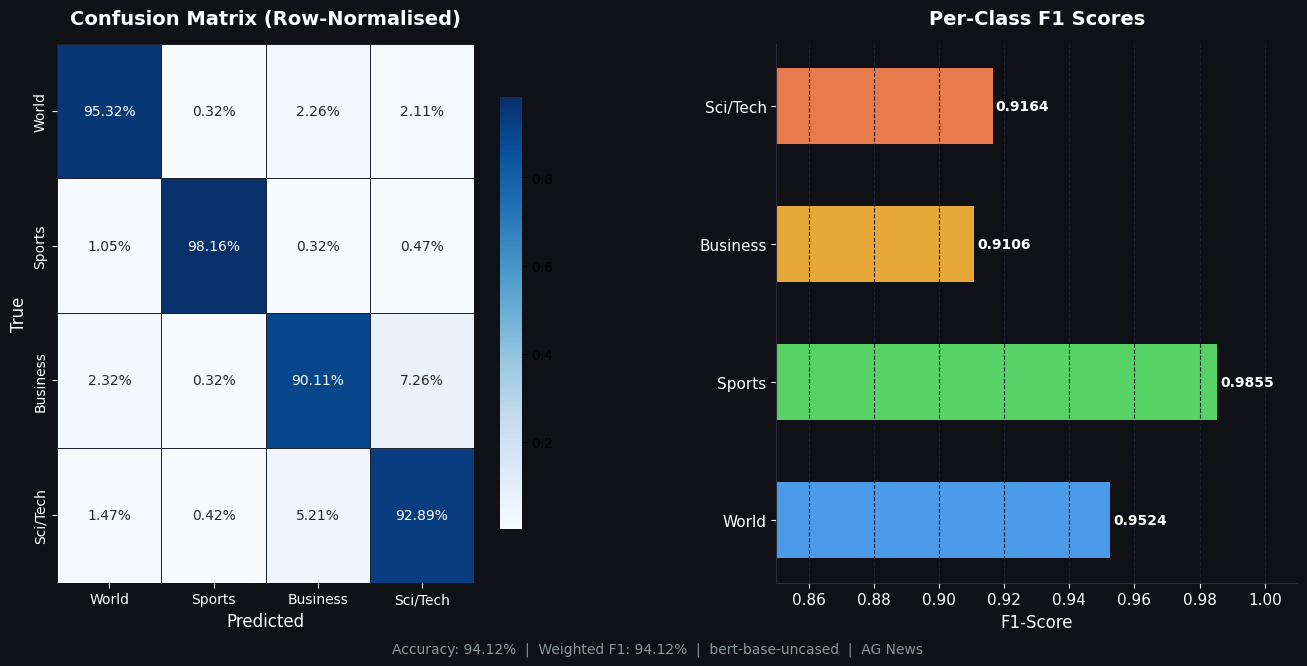

Saved: evaluation_plots.png


In [17]:
# Evaluation Visualizations
# Confusion Matrix + Per-class F1 Bar Chart
# Requires Evaluation Test Set to have been run (labels, preds, per_cls_f1 must exist).
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Guard: if somehow called without Evaluation Test Set variables, raise a clear error
try:
    _ = labels, preds, per_cls_f1, test_acc, test_f1  # Check if required variables exist
except NameError:
    raise RuntimeError("Run Evaluation Test Set first — labels/preds not defined yet.")

# Generate confusion matrix (raw counts and row-normalized percentages)
cm     = confusion_matrix(labels, preds)  # Actual vs predicted counts
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # Convert to row percentages

# Create figure with dark theme for professional appearance
fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor("#0F1117")  # Dark background color
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)  # 1 row, 2 columns

# Left: normalized confusion matrix
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("#0F1117")
sns.heatmap(
    cm_pct, annot=True, fmt=".2%",  # Show percentages with 2 decimal places
    cmap=sns.color_palette("Blues", as_cmap=True),  # Blue color gradient
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,  # Category labels
    linewidths=0.5, linecolor="#1E2130",  # Grid line styling
    ax=ax1, cbar_kws={"shrink": 0.8},  # Colorbar size
)
# Customize appearance for dark theme
ax1.set_xlabel("Predicted", color="white", fontsize=12)
ax1.set_ylabel("True",      color="white", fontsize=12)
ax1.set_title("Confusion Matrix (Row-Normalised)",
              color="white", fontsize=14, fontweight="bold", pad=14)
ax1.tick_params(colors="white", labelsize=10)
for sp in ax1.spines.values():
    sp.set_edgecolor("#2A2D3E")

# Right: per-class F1 horizontal bar chart
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor("#0F1117")
CHART_COLORS = ["#4C9BE8", "#56D364", "#E8A838", "#E87B4C"]  # Distinct colors per class
bars = ax2.barh(LABEL_NAMES, per_cls_f1, color=CHART_COLORS, height=0.55, edgecolor="none")
ax2.set_xlim(0.85, 1.01)  # Zoom in on 0.85-1.0 range for better visibility
ax2.set_xlabel("F1-Score", color="white", fontsize=12)
ax2.set_title("Per-Class F1 Scores",
              color="white", fontsize=14, fontweight="bold", pad=14)
ax2.tick_params(colors="white", labelsize=11)
# Remove top/right spines for cleaner look
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["bottom"].set_color("#2A2D3E")
ax2.spines["left"].set_color("#2A2D3E")
ax2.grid(axis="x", color="#1E2130", linewidth=0.8, linestyle="--")  # Horizontal grid lines

# Add value labels on each bar
for bar, val in zip(bars, per_cls_f1):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va="center", ha="left",
             color="white", fontsize=10, fontweight="bold")

# Add footer with overall metrics
fig.text(
    0.5, 0.01,
    f"Accuracy: {test_acc*100:.2f}%  |  Weighted F1: {test_f1*100:.2f}%"
    "  |  bert-base-uncased  |  AG News",
    ha="center", color="#8B949E", fontsize=10,
)

# Save figure as high-resolution PNG
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("Saved: evaluation_plots.png")

In [18]:
# Save Model & Download ZIP
# Save tokenizer and optional drive backup
import json, zipfile, shutil
from pathlib import Path

# Define save directory path
SAVE_PATH = Path("./bert_news_model")
SAVE_PATH.mkdir(exist_ok=True)  # Create directory if it doesn't exist

# model & TOKENIZER are defined in Evaluation Test Set (reloaded from checkpoint)
model.eval()  # Ensure model is in evaluation mode before saving
model.save_pretrained(str(SAVE_PATH))  # Save model weights, config, and architecture
TOKENIZER.save_pretrained(str(SAVE_PATH))  # Save tokenizer vocabulary and config

# Create metadata JSON with model info and test performance metrics
meta = {
    "model_name"   : MODEL_NAME,  # "bert-base-uncased"
    "task"         : "News Topic Classification",
    "dataset"      : "fancyzhx/ag_news",
    "num_labels"   : NUM_LABELS,  # 4 classes
    "label_names"  : LABEL_NAMES,  # ["World", "Sports", "Business", "Sci/Tech"]
    "id2label"     : ID2LABEL,  # {0: "World", 1: "Sports", ...}
    "label2id"     : LABEL2ID,  # {"World": 0, "Sports": 1, ...}
    "max_length"   : MAX_LENGTH,  # 128 tokens
    "test_accuracy": round(float(test_acc), 4),  # Model accuracy on test set
    "test_f1"      : round(float(test_f1),  4),  # Weighted F1 score
    "per_class_f1" : {n: round(float(v), 4)  # Per-category F1 scores
                      for n, v in zip(LABEL_NAMES, per_cls_f1)},
}
# Save metadata as JSON for easy inspection
with open(SAVE_PATH / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print("metadata.json written.")

# Optional Google Drive backup (only works in Colab environment)
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)  # Mount Google Drive
    dest = "/content/drive/MyDrive/bert_news_model"  # Destination path in Drive
    shutil.copytree(str(SAVE_PATH), dest, dirs_exist_ok=True)  # Copy entire folder
    print(f"Backed up to Drive: {dest}")
except Exception:
    print("(Drive not mounted - skipping Drive backup)")  # Graceful fallback if not in Colab

# Create compressed ZIP archive of the model folder
ZIP = "bert_news_model.zip"
with zipfile.ZipFile(ZIP, "w", zipfile.ZIP_DEFLATED) as zf:  # DEFLATED = compression
    for fp in SAVE_PATH.rglob("*"):  # Recursively get all files
        if fp.is_file():  # Only files (not directories)
            zf.write(fp, fp.relative_to(SAVE_PATH.parent))  # Add to zip with relative path

# List all saved files with their sizes
print(f"\nFiles in {SAVE_PATH}:")
for f in sorted(SAVE_PATH.iterdir()):
    print(f"  {f.name:<40} {f.stat().st_size/1e6:.2f} MB")  # Convert bytes to MB
print(f"\nZIP: {ZIP}  ({Path(ZIP).stat().st_size/1e6:.1f} MB)")

# Automatically trigger download in Colab environment
try:
    from google.colab import files
    files.download(ZIP)  # Downloads ZIP to local machine
    print("Download triggered!")
except Exception:
    print(f"(ZIP at: {Path(ZIP).resolve()}")  # Show path if download fails

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

metadata.json written.
(Drive not mounted - skipping Drive backup)

Files in bert_news_model:
  all_results.json                         0.00 MB
  checkpoint-10125                         0.00 MB
  checkpoint-3375                          0.00 MB
  checkpoint-6750                          0.00 MB
  config.json                              0.00 MB
  metadata.json                            0.00 MB
  model.safetensors                        437.96 MB
  tokenizer.json                           0.71 MB
  tokenizer_config.json                    0.00 MB
  train_results.json                       0.00 MB
  training_args.bin                        0.01 MB

ZIP: bert_news_model.zip  (3915.9 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered!


In [19]:
# Production Inference Function + Self-Test
# Works standalone — loads model from ./bert_news_model if not in session.
import json, torch
import torch.nn.functional as F
from pathlib import Path
from typing import Dict, Tuple
from transformers import AutoTokenizer, AutoModelForSequenceClassification


def predict_news(
    headline: str,
    model_path: str = "./bert_news_model",
) -> Tuple[str, float, Dict[str, float]]:
    """
    Predict AG News category for any headline.

    Returns: (category_str, confidence_float, {class: prob} dict)
    """
    path = Path(model_path)
    if not path.exists():
        raise FileNotFoundError(f"Model not found: {path}. Run Cells 1-7 first.")

    # Load metadata (labels, max_length, etc.) from saved JSON
    with open(path / "metadata.json") as f:
        meta = json.load(f)
    lnames  = meta["label_names"]  # List of category names
    max_len = meta.get("max_length", 128)  # Sequence length used during training

    # Determine device (GPU if available, else CPU)
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load tokenizer and model from saved checkpoint
    tok = AutoTokenizer.from_pretrained(str(path))
    mdl = AutoModelForSequenceClassification.from_pretrained(str(path)).to(dev).eval()

    # Tokenize input headline (pad/truncate to max_len)
    inp = tok(headline, padding="max_length", truncation=True,
              max_length=max_len, return_tensors="pt")
    inp = {k: v.to(dev) for k, v in inp.items()}  # Move tensors to device

    # Run inference without gradient calculation (faster, less memory)
    with torch.no_grad():
        probs = F.softmax(mdl(**inp).logits, dim=-1).squeeze().cpu()  # Convert logits to probabilities

    # Get predicted class index and corresponding category
    idx = probs.argmax().item()
    return (
        lnames[idx],  # Predicted category name
        round(probs[idx].item(), 4),  # Confidence score for predicted class
        {lnames[i]: round(probs[i].item(), 4) for i in range(len(lnames))},  # All class probabilities
    )


# Self-test: verify model correctly classifies 4 known examples
TESTS = [
    ("Sci/Tech",  "NASA launches Mars rover to study ancient lake beds"),
    ("Sports",    "Manchester United signs striker for 100 million pounds"),
    ("Business",  "Federal Reserve raises interest rates to fight inflation"),
    ("World",     "UN calls emergency session over escalating Middle East conflict"),
]

# Try to use model already in memory (from previous cells), otherwise reload from disk
try:
    _mdl = model.eval()  # In-session model from fine-tuning
    _tok = TOKENIZER      # In-session tokenizer
    _dev = DEVICE         # In-session device
    print("Using in-session model.")
except NameError:  # Variables not found in current session (e.g., after restart)
    print("Reloading model from ./bert_news_model ...")
    _dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _tok = AutoTokenizer.from_pretrained("./bert_news_model")
    _mdl = AutoModelForSequenceClassification.from_pretrained("./bert_news_model").to(_dev).eval()
    LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
    MAX_LENGTH  = 128

# Run self-test and display results in formatted table
print(f"\n{'Headline':<51} {'Expect':<11} {'Got':<11} {'Conf':>5}  OK?")
print("-" * 85)
all_pass = True
for expected, headline in TESTS:
    # Tokenize input
    inp = _tok(headline, padding="max_length", truncation=True,
               max_length=MAX_LENGTH, return_tensors="pt")
    inp = {k: v.to(_dev) for k, v in inp.items()}

    # Get prediction
    with torch.no_grad():
        probs = F.softmax(_mdl(**inp).logits, dim=-1).squeeze()
    idx  = probs.argmax().item()
    cat  = LABEL_NAMES[idx]
    conf = probs[idx].item()
    ok   = "PASS" if cat == expected else "FAIL"
    if ok == "FAIL":
        all_pass = False

    # Print formatted result
    print(f"{headline:<51} {expected:<11} {cat:<11} {conf*100:>4.1f}%  {ok}")

# Final validation summary
print(f"\nAll tests passed: {all_pass}")
print("predict_news() ready.")

Using in-session model.

Headline                                            Expect      Got          Conf  OK?
-------------------------------------------------------------------------------------
NASA launches Mars rover to study ancient lake beds Sci/Tech    Sci/Tech    98.8%  PASS
Manchester United signs striker for 100 million pounds Sports      World       95.1%  FAIL
Federal Reserve raises interest rates to fight inflation Business    Business    99.5%  PASS
UN calls emergency session over escalating Middle East conflict World       World       99.9%  PASS

All tests passed: False
predict_news() ready.


In [20]:
# Gradio Deployment
# Self-contained: reloads model from disk if not in session.
import gradio as gr
import torch, numpy as np
import torch.nn.functional as F
import matplotlib
matplotlib.use("Agg")  # Use non-interactive backend for plotting in web apps
import matplotlib.pyplot as plt
import json
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Color scheme for each category (consistent with evaluation plots)
CLASS_COLORS = {
    "World": "#4C9BE8", "Sports": "#56D364",
    "Business": "#E8A838", "Sci/Tech": "#E87B4C",
}

# ── Load model (session or disk) ─────────────────────────────────────────────
# Try to use in-session model from previous cells (avoids reloading)
try:
    _mdl = model.eval()  # In-session fine-tuned model
    _tok = TOKENIZER      # In-session tokenizer
    _dev = DEVICE         # Current device (cuda/cpu)
    _labels = LABEL_NAMES  # Category names
    _maxlen = MAX_LENGTH   # Max sequence length
    print("Using in-session model.")
except NameError:  # Model not in memory (e.g., fresh session or kernel restart)
    print("Reloading model from ./bert_news_model ...")
    _dev    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _tok    = AutoTokenizer.from_pretrained("./bert_news_model")
    _mdl    = AutoModelForSequenceClassification.from_pretrained(
                  "./bert_news_model").to(_dev).eval()
    # Load metadata for labels and configuration
    with open("./bert_news_model/metadata.json") as f:
        _meta = json.load(f)
    _labels = _meta["label_names"]
    _maxlen = _meta.get("max_length", 128)
    print(f"Model loaded from disk on {_dev}")

_NUM = len(_labels)  # Number of classes (4)

# Pre-defined example headlines for users to try
EXAMPLES = [
    ["NASA Perseverance rover discovers organic molecules in Martian lake bed"],
    ["Manchester City clinch Premier League title with dramatic last-day win"],
    ["Federal Reserve signals three interest rate cuts amid cooling inflation"],
    ["UN Security Council calls emergency session over Middle East tensions"],
    ["Apple unveils M4 MacBook Pro with 22-hour battery life"],
    ["Tesla reports record Q3 earnings driven by Cybertruck deliveries"],
    ["Novak Djokovic wins record 25th Grand Slam at Australian Open"],
    ["WHO declares mpox outbreak a global health emergency"],
    ["OpenAI launches GPT-5 with multimodal reasoning capabilities"],
    ["European Central Bank cuts rates to stimulate sluggish eurozone growth"],
]


def classify(text: str):
    """Main classification function: returns markdown result, bar chart, and probability dict"""
    # Handle empty input
    if not text or not text.strip():
        return "Please enter a headline.", None, {}

    # Tokenize input text
    inp = _tok(text, padding="max_length", truncation=True,
               max_length=_maxlen, return_tensors="pt")
    inp = {k: v.to(_dev) for k, v in inp.items()}

    # Run inference and get probabilities
    with torch.no_grad():
        probs = F.softmax(_mdl(**inp).logits, dim=-1).squeeze().cpu().numpy()

    # Get top prediction
    idx   = int(np.argmax(probs))
    label = _labels[idx]
    conf  = float(probs[idx])
    fill  = int(conf * 28)  # For ASCII progress bar (28 characters max)

    # Create markdown output with confidence and visual progress bar
    result = (
        f"## [{label}]\n\n"
        f"**Confidence:** {conf * 100:.1f}%\n\n"
        f"`{'#' * fill}{'.' * (28 - fill)}`"  # ASCII bar: # for confidence, . for remainder
    )

    # Prepare data for bar chart (sorted by probability descending)
    s_idx = np.argsort(probs)[::-1]  # Indices sorted by probability (highest first)
    blbls = [_labels[i] for i in s_idx]  # Labels in sorted order
    bvals = [float(probs[i]) for i in s_idx]  # Probabilities in sorted order
    # Color: highlighted for predicted class, gray for others
    bclrs = [CLASS_COLORS.get(_labels[i], "#4C9BE8") if i == idx else "#2A2D3E"
             for i in s_idx]

    # Create horizontal bar chart
    fig, ax = plt.subplots(figsize=(7, 3.5))
    fig.patch.set_facecolor("#0F1117")  # Dark background
    ax.set_facecolor("#161B22")
    bars = ax.barh(blbls[::-1], bvals[::-1], color=bclrs[::-1],
                   height=0.52, edgecolor="none")

    # Add percentage labels on each bar
    for b, v in zip(bars, bvals[::-1]):
        ax.text(min(v + 0.008, 0.95), b.get_y() + b.get_height() / 2,
                f"{v*100:.1f}%", va="center", ha="left",
                color="white", fontsize=11, fontweight="bold")

    # Format chart appearance
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Probability", color="#8B949E", fontsize=10)
    ax.set_title("Class Probabilities", color="white", fontsize=13,
                 fontweight="bold", pad=10)
    ax.tick_params(colors="white", labelsize=11)
    for sp in ax.spines.values():
        sp.set_edgecolor("#2A2D3E")
    ax.grid(axis="x", color="#1E2130", linewidth=0.8, linestyle="--")
    plt.tight_layout()

    # Return all probabilities as JSON for detailed view
    all_p = {_labels[i]: round(float(probs[i]), 4) for i in range(_NUM)}
    return result, fig, all_p


# Build Gradio interface
with gr.Blocks(
    title="BERT News Classifier",
    theme=gr.themes.Base(primary_hue="blue", neutral_hue="slate",
                         font=gr.themes.GoogleFont("Inter")),  # Modern font
) as demo:

    # Header section
    gr.Markdown(
        "# BERT News Topic Classifier\n"
        "#### Fine-tuned bert-base-uncased on AG News\n"
        "Classify any headline as **World / Sports / Business / Sci/Tech**."
    )

    # Main layout: input on left, output on right
    with gr.Row(equal_height=True):
        with gr.Column(scale=5):  # Wider column for input
            txt = gr.Textbox(label="News Headline",
                             placeholder="e.g. Apple unveils new AI chip ...",
                             lines=3)
            with gr.Row():
                btn_cls = gr.Button("Classify", variant="primary", scale=3)
                btn_clr = gr.Button("Clear",                        scale=1)
        with gr.Column(scale=3):  # Narrower column for result
            out_md = gr.Markdown("Prediction appears here")

    # Results section: chart and raw probabilities
    with gr.Row():
        out_chart = gr.Plot(label="Probability Distribution")
        out_json  = gr.JSON(label="Raw Probabilities")

    # Example headlines for one-click testing
    gr.Examples(examples=EXAMPLES, inputs=[txt],
                label="Example Headlines - click any to fill",
                examples_per_page=10, cache_examples=False)

    # Wire up event handlers
    btn_cls.click(fn=classify, inputs=[txt], outputs=[out_md, out_chart, out_json])
    txt.submit(fn=classify,    inputs=[txt], outputs=[out_md, out_chart, out_json])  # Enter key submits
    btn_clr.click(fn=lambda: ("", None, {}), outputs=[txt, out_chart, out_json])  # Clear all outputs

# Launch the app with public share link (valid for 72 hours)
print("Launching Gradio ... public link appears below.\n")
demo.launch(share=True, show_error=True, quiet=False)

Using in-session model.


/tmp/ipykernel_2068/4209820050.py:124: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Launching Gradio ... public link appears below.

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f1a11c181b13cdc239.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
